<a href="https://colab.research.google.com/github/chandu01432/Upskill/blob/main/DSA%20part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#DSA2 File link: https://colab.research.google.com/drive/17RDR4r2fGwoLZoYbSNL1emo0FOxr812A?usp=sharing

#Tree
- Its a heirarchical data structure(not linear like a list)
- It's made up of nodes connected by edges
- has a root node(starting point)
- Each node may have children

**Examples**
- Family Tree
- Folder in a Folder

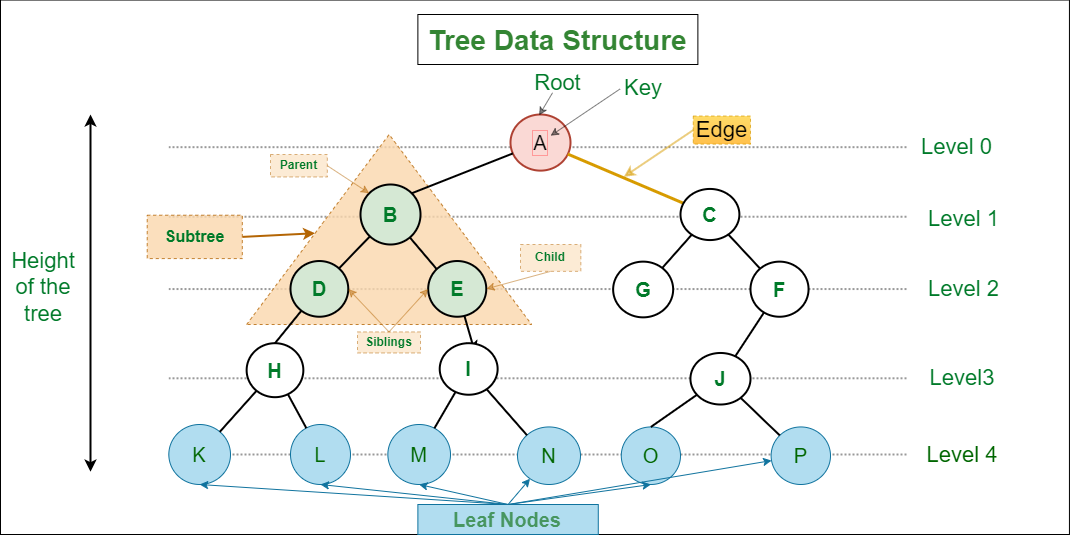

#Binary Tree
- It's a type of tree data structure where each node has at most 2 children(0,1 or 2)
- Left child
- Right child

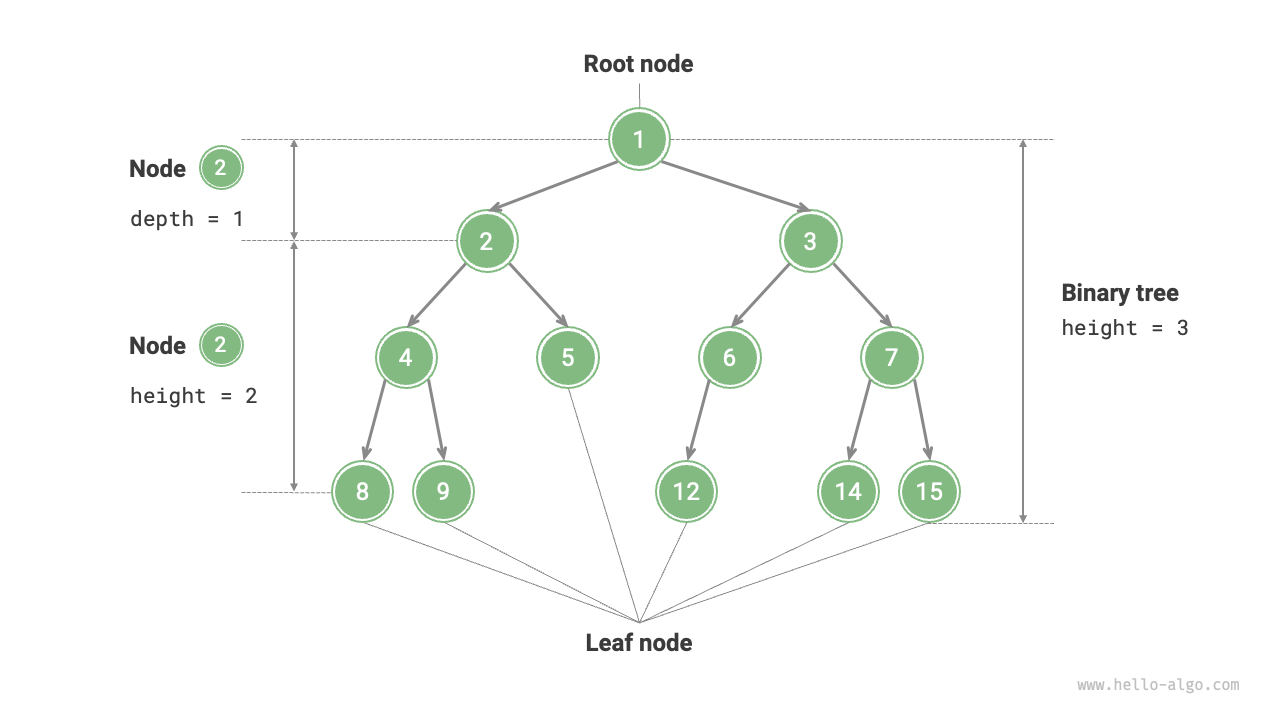

In [ ]:
class Node:
  def __init__(self,value):
    self.left=None
    self.right=None
    self.value=value

  def inorder(self,root): #left->root->right
    if root:
      self.inorder(root.left)
      print(root.value, end=" ")
      self.inorder(root.right)

  def preorder(self,root): #root->left->right
    if root:
      print(root.value, end=" ")
      self.preorder(root.left)
      self.preorder(root.right)

  def postorder(self,root): #left->right->root
    if root:
      self.postorder(root.left)
      self.postorder(root.right)
      print(root.value, end=" ")

  def print_tree(self,root,level=0,prefix="Root:"):
    if root is not None:
      self.print_tree(root.right, level+1,"     R-----")
      print("  "*level+prefix+str(root.value))  #"    "*level= identation+prefix+str(root.value) = Concatenation
      self.print_tree(root.left, level+1,"     L-----")

root=Node(10)
root.left=Node(5)
root.right=Node(15)
root.left.left=Node(2)
root.left.right=Node(7)
root.right.left=Node(12)

print(root.inorder(root))
print(root.preorder(root))
print(root.postorder(root),"\n")
root.print_tree(root)

2 5 7 10 12 15 None
10 5 2 7 15 12 None
2 7 5 12 15 10 None 

       R-----15
         L-----12
Root:10
         R-----7
       L-----5
         L-----2


#Binary Search Tree
- special kind of binary tree
- each node has atmost 2 children(0,1,2)
- Left child contains value less than the node
- Right child contains value greater than the node

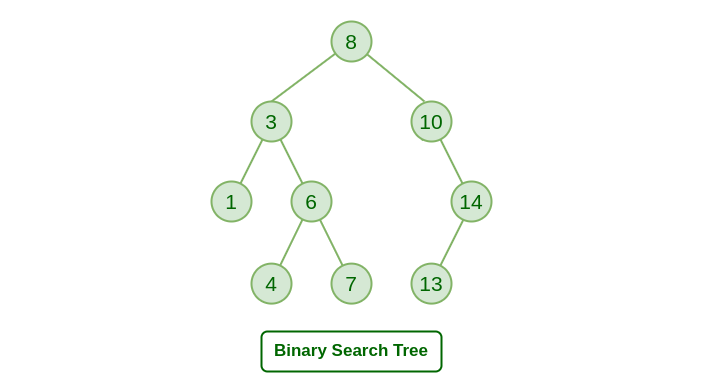

In [ ]:
class BST: #Node creation
  def __init__(self,data):
    self.data=data
    self.left=None
    self.right=None

#in pure bst definition, duplicates aren't allowed, but in practical implementation,duplicates can exist but should be handled
  def insert(self,root,data):
    if root is None:
      return BST(data)
    if data == root.data:
      return
    if data<root.data:
      root.left=self.insert(root.left,data)
    else:
      root.right=self.insert(root.right,data)
    return root

  def search(self,root,target):
    if root is None:
      return False
    if root.data == target:
      return True
    elif target<root.data:
      return self.search(root.left,target)
    else:
      return self.search(root.right,target)

  def inorder(self,root):
        if root:
            self.inorder(root.left)
            print(root.data)
            self.inorder(root.right)
        else:
            return

  def preorder(self,root):
        if root:
            print(root.data)
            self.preorder(root.left)
            self.preorder(root.right)
        else:
            return

  def postorder(self,root):
        if root:
            self.postorder(root.left)
            self.postorder(root.right)
            print(root.data)
        else:
            return

  def delete(self,root,key):
    if root is None:
      return root

    if key<root.data: #if key is smaller than the current node, go left
       root.left=self.delete(root.left,key)
    elif key>root.data:
      root.right=self.delete(root.right,key)
    else: #Case 0 and Case 1
      if root.left is None:
        return root.right
      elif root.right is None:
        return root.left

        #Case 2: Node has 2 children
        #find min node in right subtree or max node in left subtree(next successor(right subtree), or last predecsor(left subtree))
        #for the node to delete
        temp =self.find_min(root.right)
        root.data=temp.data #updating
        root.right=self.delete(root.right,temp.data)

    return root

  def find_min(self,node):
    current=node
    while current.left is not None:
      current=current.left
    return current

   #draft the code for printing tree

bst=BST(None)
root=None
values=[50,30,70,20,40,60,80]
for val in values:
  root=bst.insert(root,val)

print("Inorder traversal")
bst.inorder(root)

print("Preorder traversal")
bst.preorder(root)

print("Postorder traversal")
bst.postorder(root)

print("\n",bst.search(root,60))
bst.search(root,100)

Inorder traversal
20
30
40
50
60
70
80
Preorder traversal
50
30
20
40
70
60
80
Postorder traversal
20
40
30
60
80
70
50

 True


False

#HEAP
- is a complete binary tree that satisfies the heap property.

**TYPES**
1. **Min Heap**: every parent node is less than or equal to its children
2. **Max Heap**:  every parent node is greater than or equal to its children


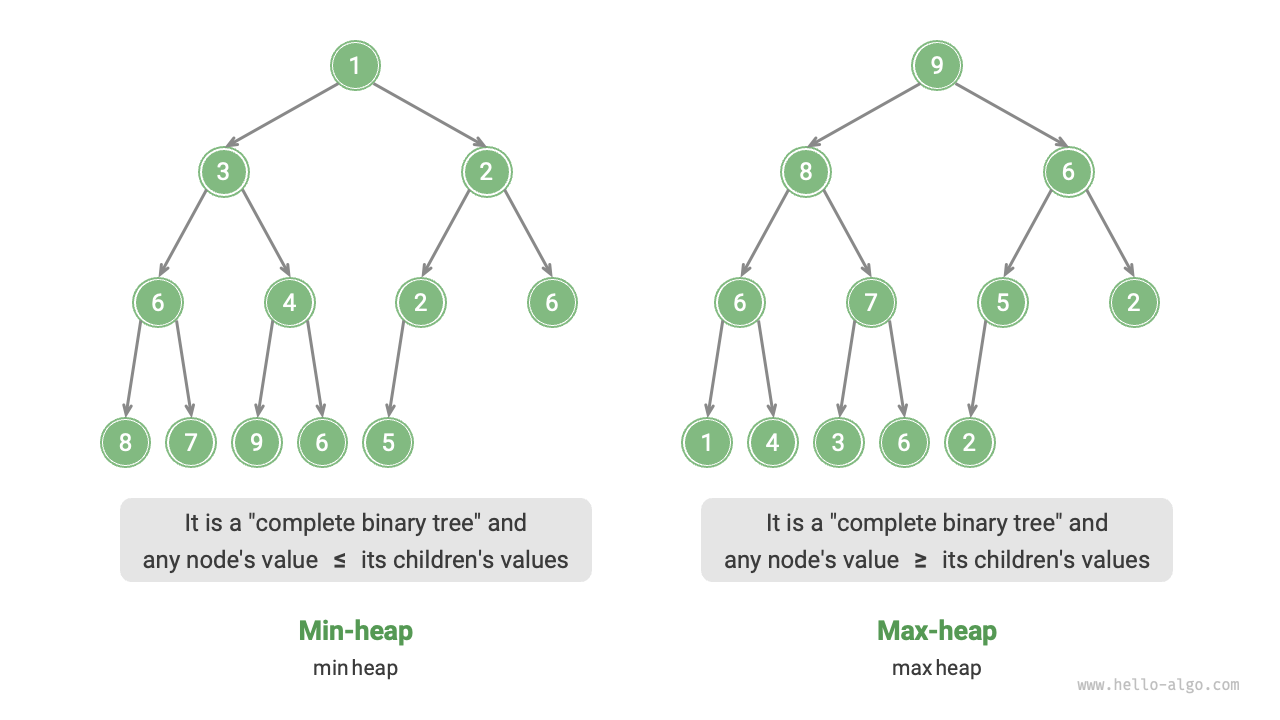

**Examples**
- CPU Scheduling = Patient
     - Patient A: critical (Priority=1)
     - Patient B: moderate (Priority=3)
     - Patient C: mild (Priority=5)

- First Rank in JEE
     

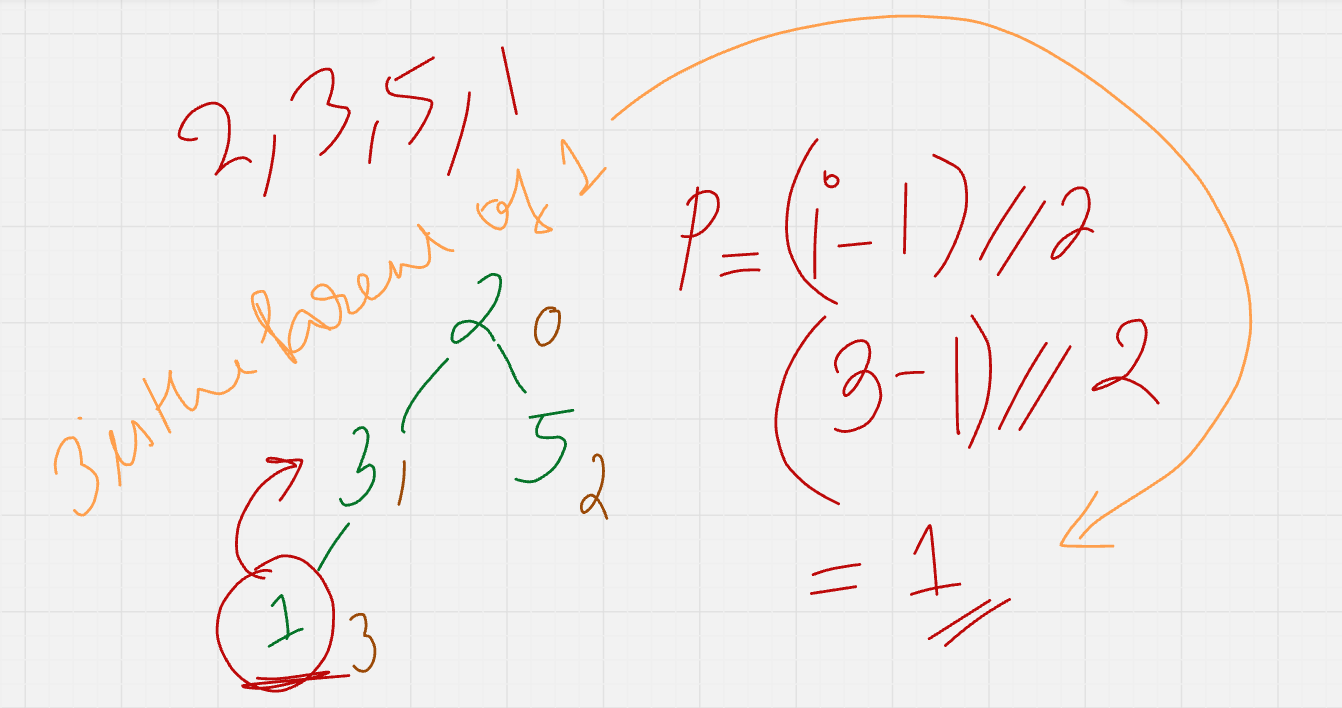

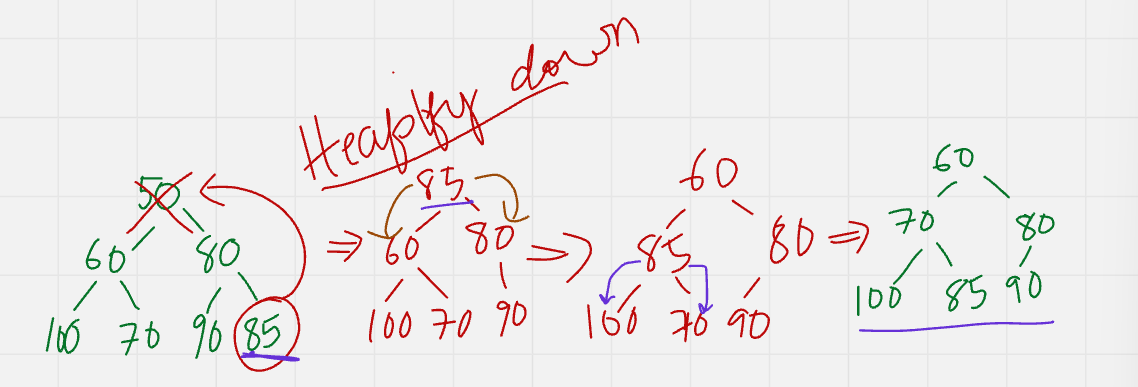

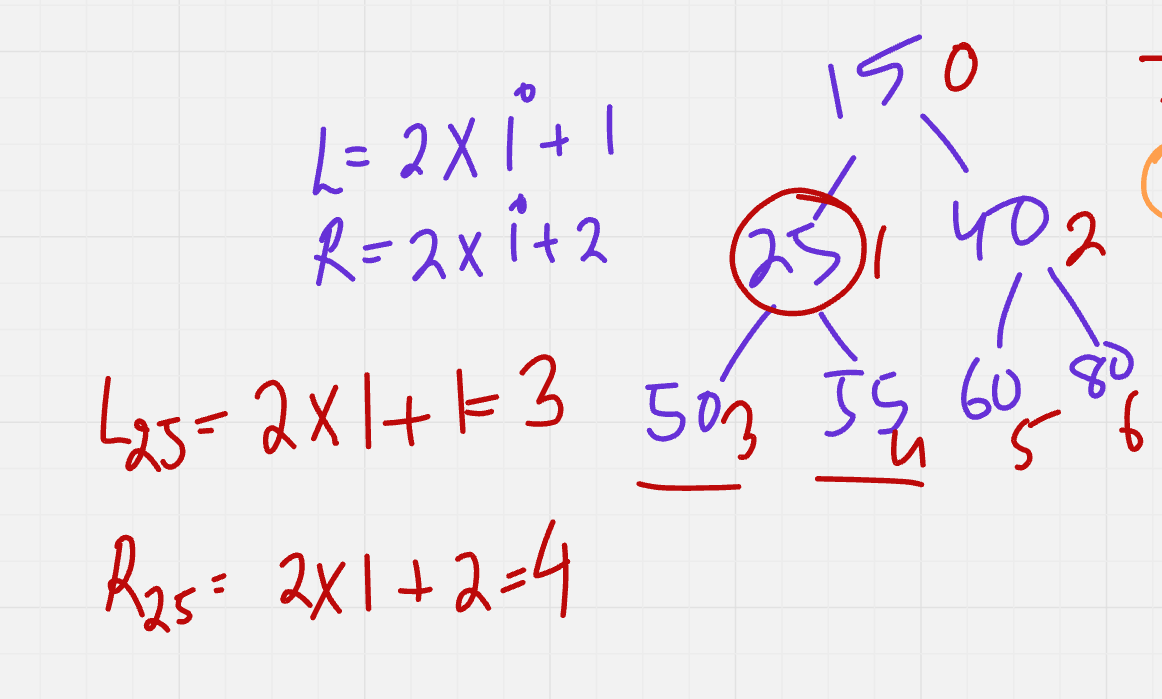

In [ ]:
class MinHeap:
  def __init__(self):
    self.heap=[] #store the elements

  def insert(self,val):
    self.heap.append(val)
    self.heapify_up(len(self.heap)-1)

  def heapify_up(self,index): #index= index of the appended value
    parent=(index-1)//2 #calc index of the parent of the current value
    if index>0 and self.heap[index]<self.heap[parent]:
      #swap if the parent is bigger
      self.heap[index],self.heap[parent]=self.heap[parent],self.heap[index]
      self.heapify_up(parent)

  def delete_min(self):
    if len(self.heap)==0:
      return None
    if len(self.heap)==1:
      return self.heap.pop()

    min_val=self.heap[0] #Root is min
    self.heap[0]=self.heap[-1] #move the last node to index 0
    self.heap.pop() #removed last node
    self.heapify_down(0)
    return min_val

  def heapify_down(self,index):
    smallest=index #assuming a node as the smallest
    left=2*index+1 #calc left child
    right=2*index+2 #calc right child

    if left<len(self.heap) and self.heap[left]<self.heap[smallest]: #comparing left value with assumed smallest value
       smallest=left
    if right<len(self.heap) and self.heap[right]<self.heap[smallest]: #comparing right value with assumed smallest value
       smallest=right
    if smallest != index:
      self.heap[index],self.heap[smallest]=self.heap[smallest],self.heap[index]
      self.heapify_down(smallest)

  def display(self):
    print(self.heap)


heap=MinHeap()

heap.insert(10)
heap.insert(5)
heap.insert(3)
heap.insert(2)
heap.insert(7)

heap.display()

min_val=heap.delete_min()
print("Deleted min value: ",min_val)

heap.display()

[2, 3, 5, 10, 7]
Deleted min value:  2
[3, 7, 5, 10]


**EXAMPLES-**
1. Leaderboard Rankings - always shows the highest scorer at the top
2. JEE/NEEt - highest scorers at the top
3. Stock Market - show top companies with max profit

In [ ]:
class MaxHeap:
  def __init__(self):
    self.heap=[] #empty list to store heap elements

  def parent(self,index):
    return (index-1)//2

  def left_child(self,index):
    return 2*index+1

  def right_child(self,index):
    return 2*index+2

  def insert(self,val):
    self.heap.append(val)
    self._heapify_up(len(self.heap)-1)

  def _heapify_up(self,index):
    if index>0 and self.heap[index]>self.heap[self.parent(index)]:
      #swap if parent is smaller
      self.heap[index],self.heap[self.parent(index)]=self.heap[self.parent(index)], self.heap[index]
      index=self.parent(index)

  def delete_max(self):
    if len(self.heap)==0:
      return None
    if len(self.heap)==1:
      return self.heap.pop()

    max_val=self.heap[0]
    self.heap[0]=self.heap[-1] #move the last to root
    self.heap.pop() #remove last
    self._heapify_down(0)
    return max_val

  def _heapify_down(self,index):
    size=len(self.heap)
    while True:
      largest=index #assuming a node as largest
      left= self.left_child(index)#calc left of this node
      right=self.right_child(index)

      if left<size and self.heap[left]>self.heap[largest]: #comparing left with assumed largest value
        largest=left
      if right<size and self.heap[right]>self.heap[largest]: #comparing right with assumed largest value
        largest=right
      if largest==index:
        break

      self.heap[index],self.heap[largest]=self.heap[largest],self.heap[index]
      index=largest

  def display(self):
   print(self.heap)


heap= MaxHeap()
heap.insert(10)
heap.insert(5)
heap.insert(3)
heap.insert(2)
heap.insert(7)

heap.display()

max_val=heap.delete_max()
print("Deleted max value:", max_val)

heap.display()

[10, 7, 3, 2, 5]
Deleted max value: 10
[7, 5, 3, 2]


#GRAPHS
- non-linear data structure consisting of:
     - **Vertices** - nodes
     - **Edges** - connection between nodes

- **Examples**
 1. Google Map - Cities/location - roads connecting them
 2. Instagram - Users - Friend requests/ Follow requests
 3. Computer Networks - PC/Router - cables/wirelessly

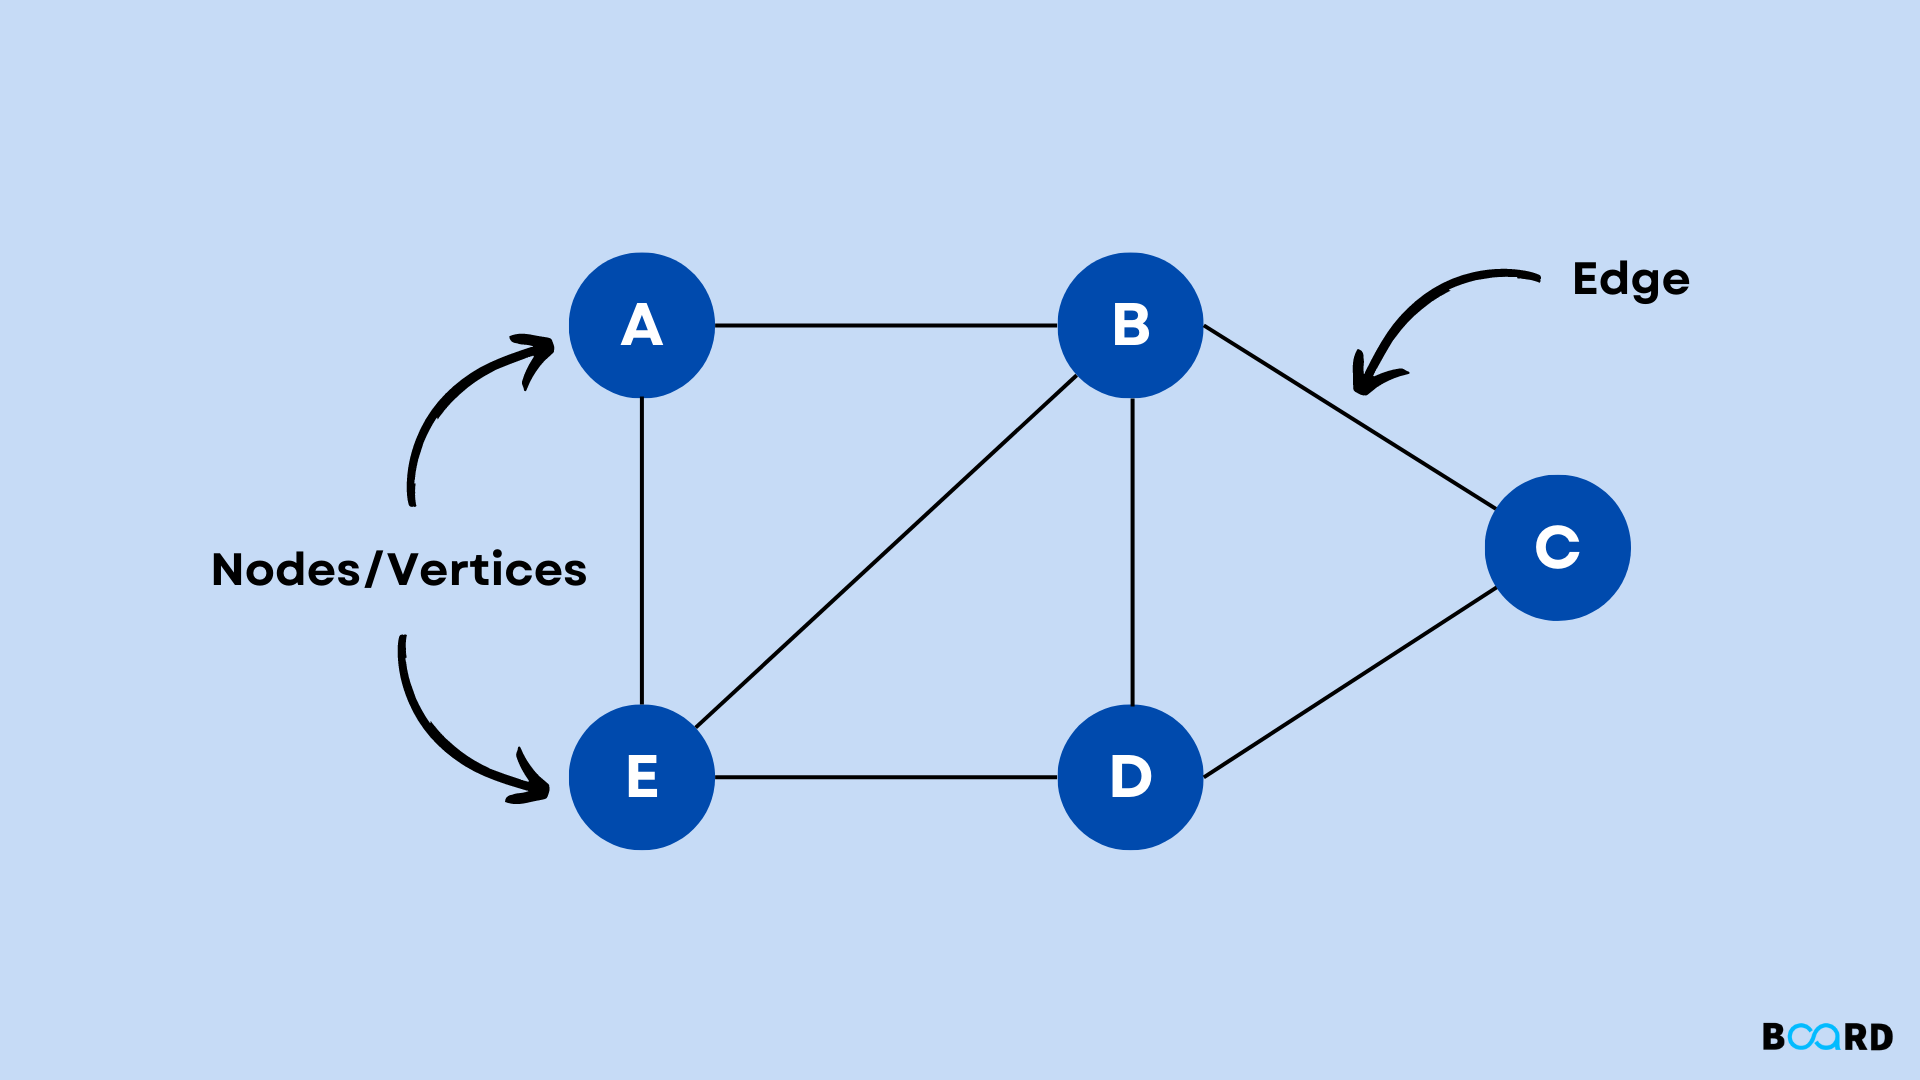

In [ ]:
graph={} #empty dict to store data

#Add a node
def add_node(node):
  if node not in graph: #if the node isn't present in the graph
    graph[node]=[] #adding node as key, and empty list as its value since no neighbors are yet made
  else:
    print(f"Node {node} already exists")

#Add an edge (make neighbours)
def add_edge(node1,node2):
  if node1 in graph and node2 in graph:
    if node2 not in graph[node1]:
      graph[node1].append(node2)
    if node1 not in graph[node2]:
      graph[node2].append(node1)
  else:
    print("One or both nodes not found")

#Delete a node
def delete_node(node):
  if node in graph: #if node is present in graph(dict)
    for other in graph: #iterating using "other" variable
      graph[other].remove(node) #removing neighbor(node) from the list
    del graph[node] #removing the node itself
  else:
    print(f"Node {node} doesn't exist")

def delete_edge(node1,node2):
  if node1 in graph and node2 in graph:
    if node2 in graph[node1]:
      graph[node1].remove(node2)
    if node1 in graph[node2]:
      graph[node2].remove(node1)
  else:
    print("One or both nodes not found")


add_node("Teena")
add_node("Priya")
add_node("Fahath")
add_node("Samikshit")
add_node("Anshul")
add_node("Varsha")
add_node("Sri Ram")

add_edge("Teena",'Anshul')
add_edge("Teena",'Varsha')
add_edge("Priya",'Fahath')
add_edge("Priya",'Samikshit')
add_edge("Fahath",'Varsha')
add_edge("Fahath",'Sri Ram')
add_edge("Samikshit",'Anshul')
add_edge('Sri Ram', 'Varsha')
add_edge("Anshul",'Priya')

print(graph)

{'Teena': ['Anshul', 'Varsha'], 'Priya': ['Fahath', 'Samikshit', 'Anshul'], 'Fahath': ['Priya', 'Varsha', 'Sri Ram'], 'Samikshit': ['Priya', 'Anshul'], 'Anshul': ['Teena', 'Samikshit', 'Priya'], 'Varsha': ['Teena', 'Fahath', 'Sri Ram'], 'Sri Ram': ['Fahath', 'Varsha']}


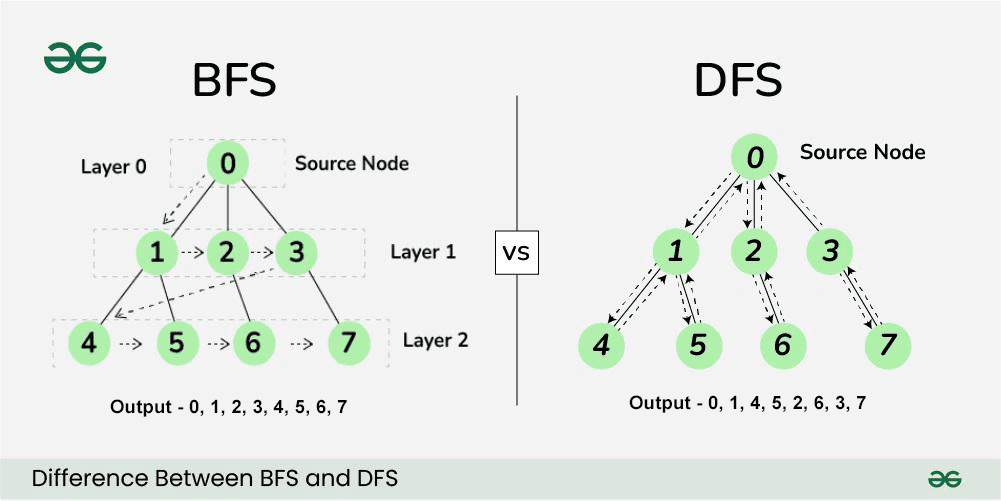

#DFS : Depth First Search
- goes deep in one path before backtracking

In [ ]:
graph1={'A':['B','C'],
        'B':['D','E'],
        'C':['F'],
        'D':[],
        'E':[],
        'F':[]}

def dfs(node,visited=None):
  if visited is None:
    visited=set() #initializing visited node
  visited.add(node) #marking current node as visited
  print(node, end=" ")

  for neighbor in graph1[node]:
    if neighbor not in visited:
      dfs(neighbor,visited)

dfs('A')

A B D E C F 

#BFS : Breadth First Search
- go layer by layer visiting each node in one layer at a time

In [ ]:
graph1={'A':['B','C'],
        'B':['D','E'],
        'C':['F'],
        'D':[],
        'E':[],
        'F':[]}

def bfs(start_node):
  visited=set() #keeps a track of visited nodes
  queue=[] #list maintaining order in which nodes should be visited(FIFO)

  queue.append(start_node)
  visited.add(start_node) #marking node as visited

  while queue:
    current=queue.pop(0) #FIFO removing from the front end
    print(current)

  for neighbor in graph1[current]:
    if neighbor not in visited:
      queue.append(neighbor)
      visited.add(neighbor)


*Question:*

* You are managing a train where each compartment has a number. Create a **linked list** of compartments, add a new compartment at the end, and delete a compartment given its number.

*Question:*

* Implement a **stack** where plates are added one on top of another. Support operations: add a plate, remove the top plate, and check which plate is currently on top.

*Question:*

* Simulate a ticket counter **queue**. Add people to the queue as they arrive, serve them one by one, and show who is next in line.

**Looking for a name in your *attendance sheet* (one by one).**

*Question:*

* Write code to search for a student’s name in a list of names.

**Looking up a word in a *dictionary/book* (you don’t start from the first page, you jump halfway).**

*Question:*

* Given a sorted list of roll numbers, use binary search to check if a particular roll number exists.

**Sorting *soap bubbles by size* (repeatedly swap adjacent ones).**

*Question:*

* Sort an array of test scores using **bubble sort**.

**Picking the *smallest mango from a basket repeatedly* until sorted.**

*Question:*

* Sort employee salaries using **selection sort**.

**Arranging *playing cards in your hand*.**

*Question:*

* Sort marks of students using **insertion sort**.

**Splitting and merging *piles of books* into sorted order.**

*Question:*

* Sort a list of book prices using **merge sort**.

**Picking a *pivot student* in a class and arranging others as “shorter” or “taller” around the class**

*Question:*

* Sort heights of players using **quick sort**.

**Think of a *family tree* or *folder structure on a computer*.**

*Question:*

* Build a **binary tree** of employees where each node has a name. Perform inorder, preorder, and postorder traversal to print employee names in different orders.

**A *phone contact list* where left child < root < right child.**

*Question:*

* Insert roll numbers into a **BST** and search for a student’s roll number.

**Think of *cities connected by roads*.**

*Question:*

1. Add a city **(node)** and connect it to other cities **(edges)**.
2. Delete a city and remove its roads.

**Think of *exploring a mall*:**

* DFS = Go deeply into one shop section before moving to the next.
* BFS = Explore all shops on the current floor before going up.

*Question:*

* Represent a city map as a graph and perform **DFS (depth-first search)** and **BFS (breadth-first search)** to explore all the cities.
